# Project 1 – Decision Trees and Random Forests

In [406]:
# Reload all modules without having to restart the kernel
# Useful for development if you have edited any of the external code files.
%load_ext autoreload
%autoreload 2

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

from sklearn.model_selection import train_test_split
# ... add more imports as needed



# Our implementations
from decision_tree import DecisionTree
from random_forest import RandomForest


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Dataset

Do data loading, exploration and preprocessing as you see fit.

Here is some code to load the dataset to get you started.

In [407]:
data = np.genfromtxt("letters.csv", delimiter=",", dtype=float, names=True)

feature_names = list(data.dtype.names[:-1])
target_name = data.dtype.names[-1]

X = np.array([data[feature] for feature in feature_names]).T
y = data[target_name].astype(int)

print(f"Feature columns names: {feature_names}")
print(f"Target column name: {target_name}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Feature columns names: ['xbox', 'ybox', 'width', 'high', 'onpix', 'xbar', 'ybar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'xege', 'xegvy', 'yege', 'yegvx']
Target column name: label
X shape: (2000, 16)
y shape: (2000,)


In [408]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,shuffle = True, random_state = 42)

# Data analysis

We go through the features and get some information from the training dataset, so we avoid looking at our test set

In [409]:

df_X_train = pd.DataFrame(X_train,columns=feature_names)
print(df_X_train.shape,y_train.shape)
print(df_X_train.head())
df_X_train.describe()

(1600, 16) (1600,)
   xbox  ybox  width  high  onpix  xbar  ybar  x2bar  y2bar  xybar  x2ybr  \
0   5.0  11.0    6.0   8.0    4.0   3.0   8.0    6.0    6.0   12.0   10.0   
1   7.0   9.0    6.0   4.0    5.0   9.0   7.0    3.0    5.0    9.0    4.0   
2   2.0   5.0    3.0   3.0    3.0   7.0   7.0    5.0    5.0    6.0    6.0   
3   4.0   9.0    4.0   4.0    4.0   8.0   7.0    3.0    4.0    9.0    6.0   
4   6.0  11.0    7.0   8.0    4.0   6.0   7.0   11.0   11.0    6.0    5.0   

   xy2br  xege  xegvy  yege  yegvx  
0   13.0   2.0    9.0   3.0    7.0  
1    7.0   7.0    5.0   7.0    8.0  
2    6.0   2.0    8.0   6.0   10.0  
3    8.0   5.0    7.0   6.0    8.0  
4    6.0   3.0    8.0   4.0    8.0  


,xbox,ybox,width,high,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybr,xy2br,xege,xegvy,yege,yegvx
count,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000
mean,3.808750,7.004375,4.919375,5.185625,3.493750,6.685000,7.238750,4.630625,5.675000,8.769375,5.820000,8.085000,2.498750,8.083750,4.443125,7.976250
std,1.703008,3.319449,1.694748,2.159649,2.003739,2.255594,2.399551,2.110858,2.357244,2.204648,2.332327,2.841931,1.702369,1.336639,2.163548,1.636264
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,2.000000,0.000000,2.000000,0.000000,2.000000
25%,3.000000,5.000000,4.000000,4.000000,2.000000,5.000000,6.000000,3.000000,4.000000,7.000000,5.000000,6.000000,1.000000,8.000000,3.000000,7.000000
50%,4.000000,7.000000,5.000000,5.500000,3.000000,7.000000,7.000000,4.000000,6.000000,8.000000,6.000000,8.000000,2.000000,8.000000,4.000000,8.000000
75%,5.000000,9.000000,6.000000,7.000000,5.000000,8.000000,8.000000,6.000000,7.000000,11.000000,7.000000,9.000000,3.000000,9.000000,6.000000,9.000000
max,11.000000,15.000000,11.000000,10.000000,12.000000,13.000000,15.000000,11.000000,12.000000,14.000000,12.000000,15.000000,9.000000,12.000000,12.000000,13.000000


We check to see how well distributed the grades A-F are.

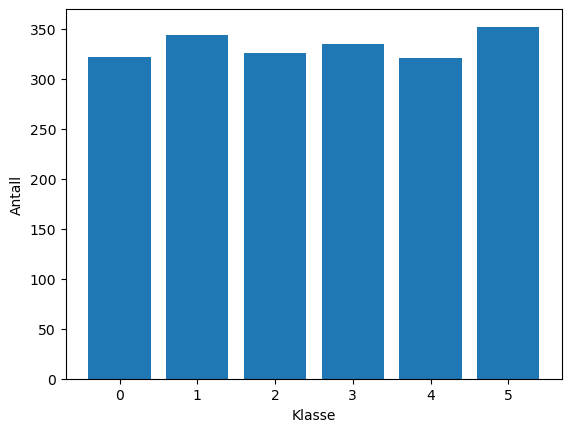

In [410]:
c = np.bincount(y.astype(int))
plt.bar(range(len(c)), c)
plt.xlabel('Klasse')
plt.ylabel('Antall')
plt.show()

Our dataset seems to be quite uniformly distributed, we therefore decide to use accuracy as our performance measurement.

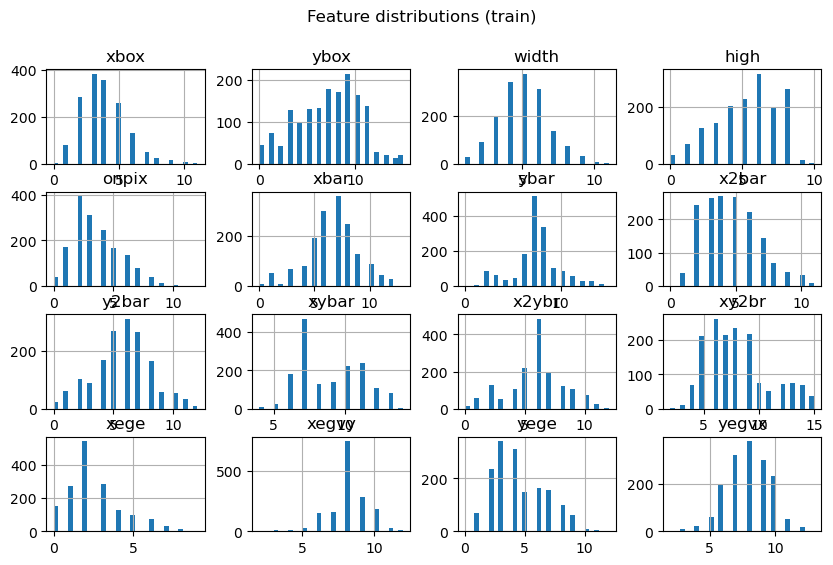

In [411]:
cols = feature_names[:]  
df_X_train[cols].hist(bins=30, figsize=(10,6))
plt.suptitle("Feature distributions (train)")
plt.show()

This histogram shows the value the feature can take (x-axis) and how many samples have that number (y-axis). This shows us how the features are clustered (if they are skewed, spread out etc)
We see that there is different scaling along the x-axis (ranges from 0-5 or from 0-15). This may affect the alrogithms sensitivity to feature scaling. There are some features who are more uniformly distributed features, like xy2br x2bar.
We have checked that there are no features with all values in one bin, as that would be useless for the classification (provides no new information).

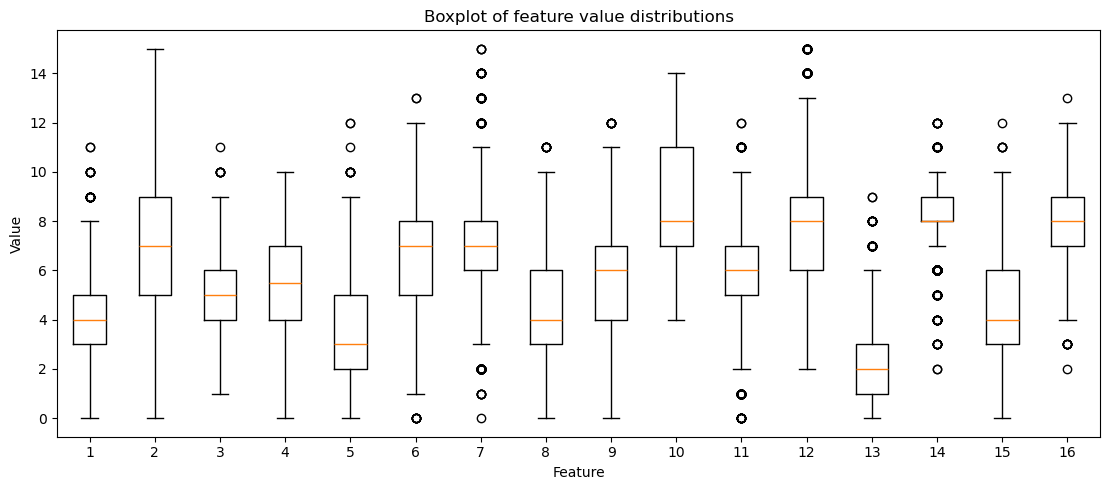

In [412]:

dfX = df_X_train.copy()


# Boxplot: én boks per feature (rå fordeling)
plt.figure(figsize=(max(10, 0.7 * len(dfX.columns)), 5))
plt.boxplot([dfX[col].astype(float).values for col in dfX.columns])
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Boxplot of feature value distributions")
plt.tight_layout()
plt.show()

This shows us more distribution of our features in the dataset. It shows the IQR,median and some outliers of each features. We see that some features have more outliers than others, can they be noise? If the IQR is small, it may contribute less to the classification (as there is little spread in the data, hence less wiggleroom to predict). We can assume that if a fature have outliers, a big IQR and the median is either not centered around the middle of the IQR, they may need more attention when we look into our tuning.

## 3.1 - Model selection
In this section, our implementation of the random forest is named our_rf, while the Sklearn-model is named sk_rf

These are the hyperparams we choose

In [413]:


rf_hyperparams =[(max_depth,n_estimators,criterion,max_features)
                for max_depth in [1,2,3,4,5,6,7,8,9,10,None]
                for n_estimators in [10,30,50,100,200] 
                for criterion in ["gini","entropy"]
                for max_features in ["log2","sqrt",None]]

In [414]:
seed = 42
skf = KFold(n_splits=5, shuffle=True, random_state=seed)
folds = list(skf.split(X_train, y_train))  # reuse same folds for all params

results_our_rf = {}
results_sk_rf = {}

for max_depth, n_estimators, criterion, max_features in rf_hyperparams:
    our_rf_fold_scores = []
    sk_rf_fold_scores = []
    for fold_id, (tr_idx, va_idx) in enumerate(folds):
        Xi, yi = X_train[tr_idx], y_train[tr_idx]
        Xv, yv = X_train[va_idx], y_train[va_idx]

        np.random.seed(seed + fold_id) # Ensure reproducibility

        our_rf = random_forest.RandomForest(max_depth=max_depth,n_estimators=n_estimators,criterion=criterion,max_features=max_features,)
        our_rf.fit(Xi, yi)
        our_rf_pred = our_rf.predict(Xv)
        our_rf_fold_scores.append(accuracy_score(y_true=yv, y_pred=our_rf_pred))  


        sk_rf = RandomForestClassifier(max_depth=max_depth,n_estimators=n_estimators,criterion=criterion,max_features=max_features)
        sk_rf.fit(Xi,yi)
        sk_rf_pred = sk_rf.predict(Xv)
        sk_rf_fold_scores.append(accuracy_score(y_true=yv,y_pred=sk_rf_pred))


    results_our_rf[(max_depth, n_estimators, criterion, max_features)] = float(np.mean(our_rf_fold_scores))
    results_sk_rf[(max_depth,n_estimators,criterion,max_features)] = float(np.mean(sk_rf_fold_scores))





# pick the best parameters for our model
our_rf_best_param, our_rf_best_cv = max(results_our_rf.items(), key=lambda kv: kv[1])
print("Our Random Forests best params:", our_rf_best_param, "| CV accuracy:", round(our_rf_best_cv, 4))


#Retrain our model with the best parameters on the entire training dataset
our_rf_best_model = random_forest.RandomForest(
    max_depth=our_rf_best_param[0],
    n_estimators=our_rf_best_param[1],
    criterion=our_rf_best_param[2],
    max_features=our_rf_best_param[3],
)
np.random.seed(seed)  # seed once for final training
our_rf_best_model.fit(X_train, y_train)
test_acc_our_rf = accuracy_score(y_test, our_rf_best_model.predict(X_test))
print("Final test accuracy for our model:", round(test_acc_our_rf, 4))



#Pick the best parameters for sklearn model
sk_rf_best_param, sk_rf_best_cv = max(results_sk_rf.items(),key=lambda kv: kv[1])
print("Sklearns Random Forests best params", sk_rf_best_param, ". CV accuracy: ",round(sk_rf_best_cv,4))

#Retrain sklearn model with the best parameters on the entire training dataset
sk_rf_best_model = RandomForestClassifier(
    max_depth=sk_rf_best_param[0],
    n_estimators=sk_rf_best_param[1],
    criterion=sk_rf_best_param[2],
    max_features=sk_rf_best_param[3]
)

np.random.seed(seed) 
sk_rf_best_model.fit(X_train,y_train)

test_acc_sk_rf = accuracy_score(y_test,sk_rf_best_model.predict(X_test))
print("Final test accuracy for sk_learn model:", round(test_acc_sk_rf,4))


Our Random Forests best params: (10, 100, 'entropy', 'log2') | CV accuracy: 0.9688
Final test accuracy for our model: 0.945
Sklearns Random Forests best params (None, 200, 'entropy', 'log2') . CV accuracy:  0.9681
Final test accuracy for sk_learn model: 0.9725


In [415]:
dt_hyperparams = [(max_depth,criterion)for max_depth in range(1,16) for criterion in ["gini","entropy"]]


In the following section we select the best parameters for our implementation of the decision tree, as well as sklearns model. Our decision tree is named our_dt, and sklears model is named sk_dt 

In [416]:


results_our_dt = {}
results_sk_dt = {}

for max_depth, criterion in dt_hyperparams:
    our_dt_fold_scores = []
    sk_dt_fold_scores = []
    for fold_id, (tr_idx, va_idx) in enumerate(folds):
        Xi, yi = X_train[tr_idx], y_train[tr_idx]
        Xv, yv = X_train[va_idx], y_train[va_idx]


        our_dt = decision_tree.DecisionTree(max_depth=max_depth,criterion=criterion)
        our_dt.fit(Xi, yi)
        our_dt_pred = our_dt.predict(Xv)
        our_dt_fold_scores.append(accuracy_score(y_true=yv, y_pred=our_dt_pred))  
        
        
        sk_dt = DecisionTreeClassifier(max_depth=max_depth,criterion=criterion)
        sk_dt.fit(Xi,yi)
        sk_dt_pred = sk_dt.predict(Xv)
        sk_dt_fold_scores.append(accuracy_score(y_true=yv,y_pred=sk_dt_pred))
        
    results_our_dt[(max_depth, criterion)] = float(np.mean(our_dt_fold_scores))
    results_sk_dt[(max_depth,criterion)] = float(np.mean(sk_dt_fold_scores))




# pick the best (maximize)
our_dt_best_param, our_dt_best_cv = max(results_our_dt.items(), key=lambda kv: kv[1])
print("Our decision trees best params:", our_dt_best_param, "| CV accuracy:", round(our_dt_best_cv, 4))

# retrain best model on full training split and evaluate once on the untouched test set
our_dt_best_model = decision_tree.DecisionTree(
    max_depth=our_dt_best_param[0],
    criterion=our_dt_best_param[1],
)
np.random.seed(seed)  # seed once for final training
our_dt_best_model.fit(X_train, y_train)
test_acc = accuracy_score(y_test, our_dt_best_model.predict(X_test))
print("Final test accuracy:", round(test_acc, 4))



sk_dt_best_param, sk_best_cv = max(results_sk_dt.items(),key=lambda kv: kv[1])
print("Sklearn decision tree best params", sk_dt_best_param, ". CV accuracy: ",round(sk_best_cv,4))
#retrain
sk_dt_best_model = DecisionTreeClassifier(
    max_depth=sk_dt_best_param[0],
    criterion=sk_dt_best_param[1]
)

np.random.seed(seed) 
sk_dt_best_model.fit(X_train,y_train)

test_acc = accuracy_score(y_test,sk_dt_best_model.predict(X_test))
print("Final test acc sk_learn = ", round(test_acc,4))


Our decision trees best params: (10, 'entropy') | CV accuracy: 0.8944
Final test accuracy: 0.9025
Sklearn decision tree best params (15, 'entropy') . CV accuracy:  0.9294
Final test acc sk_learn =  0.9175


# 4 - Feature importance

We choose the best features from the random forest, and train it on X_train and y_train

We use this model to find the most important features, by first establishing a baseline accuracy for the model on X_test. After establishing a baseline, we test the model on X_test with each feature i shuffled randomly n times. The average difference between the baseline accuracy and the accuracy when feature i is shuffled is recorded, and returned from the method RandomForest.permutation_importance()

In [417]:
    
best_model = random_forest.RandomForest(
    max_depth=our_rf_best_param[0],
    n_estimators=our_rf_best_param[1],
    criterion=our_rf_best_param[2],
    max_features=our_rf_best_param[3],
)
np.random.seed(seed)  # seed once for final training
best_model.fit(X_train, y_train)

metric = accuracy_score

imp = best_model.permutation_importance(X_test,y_test,metric=metric,n_repeats=30,seed=42)
feature_names = list(data.dtype.names[:-1])


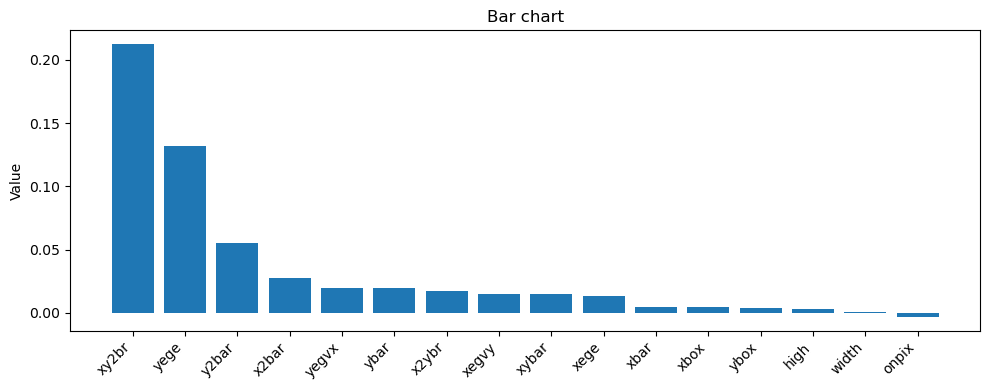

In [418]:

order = np.argsort(-np.asarray(imp))
x = np.asarray(feature_names)[order]
y = np.asarray(imp)[order]
plt.figure(figsize=(10,4))
idx = np.arange(len(x))
plt.bar(idx, y)
plt.xticks(idx, x, rotation=45, ha='right')
plt.ylabel("Value")
plt.title("Bar chart")
plt.tight_layout()
plt.show()